# Buyback-Drift — a quantitative teardown 🔬
### Abnormal-return event study · forward drift vs zero · a one-sample *t* + same-names placebo null · a size-split robustness cut · costs · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "the stock drifts up" fuses: a **real but small** post-authorization abnormal drift from the **unconditional up-drift** of equities, and we confront both with the **sample size**. The decisive object is not the sign of the point estimate (it's positive, as the 1995 underreaction literature says) but its **power**: with ~30 single-name events, the mean abnormal drift is statistically indistinguishable from re-entering the same names on random dates.

> ⚠️ **Data + sample note.** Point-in-time authorization feeds aren't on yfinance; we hard-code a transparent **sample** of 32 notable mega-cap authorizations (visibility- and survivorship-selected, both named on the Signal axis), enter **one day after** the announcement (so we measure drift, **not** the day-0 jump), and measure **abnormal** returns (stock − SPY). Real data: yfinance daily adjusted closes, 2010→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buyback_drift import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
print("real event-price cache present:", HAVE_REAL,
      "| authorizations in table:", len(data.event_table()))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'n_events': 32, 'h1': (1, 32, 0.52, 0.67, 59, 0.72, 0.392), 'h3': (3, 32, 2.42, 0.91, 53, 1.19, 0.2), 'h6': (6, 32, 4.49, 1.12, 56, 1.21, 0.165), 'h12': (12, 32, 5.34, 1.69, 53, 0.87, 0.338), 'net': [(1, 0.52, 0.42), (3, 2.42, 2.32), (6, 4.49, 4.39)], 'size': [('BIG (>=median)', 16, 2.81, 0.52, 0.612), ('SMALL (<median)', 16, 6.17, 1.19, 0.042)], 'syn': [(0.0, 31, 2.62, 0.66), (0.15, 31, 10.61, 2.47)]}


real event-price cache present: True | authorizations in table: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 6-month abnormal mean **+4.5%** at one-sample **t = 1.21** (best horizon), placebo **p = 0.17** — positive but **fails t ≥ 2** at every horizon; median event **+1.1%**, win-rate **56%** (≈ coin-flip). |
| **Tradability** | `FRAGILE` | **32 single-name events**; per-trade drift inside its SE; net of 10-bps costs intact; **dose-response inverted** (bigger programs drift *less*: **+2.8%** vs **+6.2%**). |
| **Free lunch?** | `BUSTED` | A same-names placebo matches the real set ~1 in 6; the documented move is the **day-0 jump** (~2–3%), excluded by the 1-day lag — the months-long drift is base rate × a few lucky names. |

> 💡 In plain words: buyback authorizations really do precede gains — because *almost everything* precedes gains, and a handful of mega-cap winners inflate the mean. Strip the market and the same-names luck, and ~30 events leave nothing the null can't explain.

## 1 · The claim, steelmanned

Let $r^{i}_{t\to t+H}$ be name $i$'s return over horizon $H$ after its announcement at $t$, and $r^{m}_{t\to t+H}$ the SPY return over the same window. The **abnormal** drift is $a^{i}_H = r^{i}_{t\to t+H} - r^{m}_{t\to t+H}$.

- **H₁ (the signal predicts).** $\mathbb{E}[a_H] > 0$ — a *positive abnormal drift* beyond the market, as Ikenberry-Lakonishok-Vermaelen (1995) report at long horizons.
- **H₂ (it's deployable).** The drift is large, frequent, and *dose-responsive* (bigger authorization ⇒ bigger drift) enough, net of costs, to allocate to.
- **H₃ ("free lunch").** The drift reflects the *authorization*, not the market's up-drift, a day-0 jump you enter after, or a few lucky names.

We find **H₁ not rejected but not supported** (positive, $t < 2$ at every horizon), **H₂ rejected** (≈30 events, inverted dose-response), **H₃ rejected** (a same-names placebo can't be beaten). The legend is true where it's uninformative (stocks go up) and unproven where it would pay (a *distinct, sizable* drift).

## 2 · So what? — what rides on each answer

The whole teardown is one estimate against its **standard error**:

$$\bar a_H = \frac1k\sum_{i=1}^{k} a^{i}_H,\qquad t = \frac{\bar a_H}{s_a/\sqrt{k}},\quad k \approx 32.$$

Single-name abnormal returns carry **full idiosyncratic volatility**, so $s_a$ is large and $s_a/\sqrt{k}$ larger still: even a few-point $\bar a_H$ drowns in its own SE. A raw **win-rate** is the wrong lens — a single-name abnormal return is ~a coin-flip around zero, so a 55% conditional rate is ≈1 SE of a proportion from the null. The honest small-sample instrument is a **same-names randomization (placebo) test**: re-enter each name on random dates and ask how often chance matches the announcement set — controlling for each stock's *own* drift and vol, not just SPY's. That number, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Event set.** A hard-coded table of **32** notable buyback **authorizations** (ticker, announce date, $bn size), 2010-01-04→2026-06-18, 4,140 price days. Explicit **visibility/survivorship-selected sample** (named on the axis).
- **Abnormal returns.** Enter the close **1 day after** the announcement (no look-ahead; excludes the day-0 jump), hold $H\in\{1,3,6,12\}$ months; $a_H = r^{\text{stock}}_H - r^{\text{SPY}}_H$. Drop events whose horizon overruns the tape.
- **Null #1 (one-sample t).** $\bar a_H$ vs 0.
- **Null #2 (same-names placebo).** 20,000 draws; each event re-entered on a random valid date *for its own ticker*; $p = \Pr[\text{placebo mean} \ge \text{ann. mean}]$ — the small-sample workhorse.
- **Robustness.** Split by program size (does dose-response hold?).
- **Costs.** 1-day lag + a 10-bps single-name round-trip.
- **Positive control.** A deterministic panel of **31 event windows** with a **known** planted abnormal drift: the inference must recover a planted edge **and** must NOT manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The point estimates — positive, small, swamped by their SE

Mean abnormal return with its $\pm$ standard error at each horizon, with the $t = 0$ line. Positive throughout, but every error bar straddles a *t* well below 2 — and the **median** (the typical event) sits far below the mean.

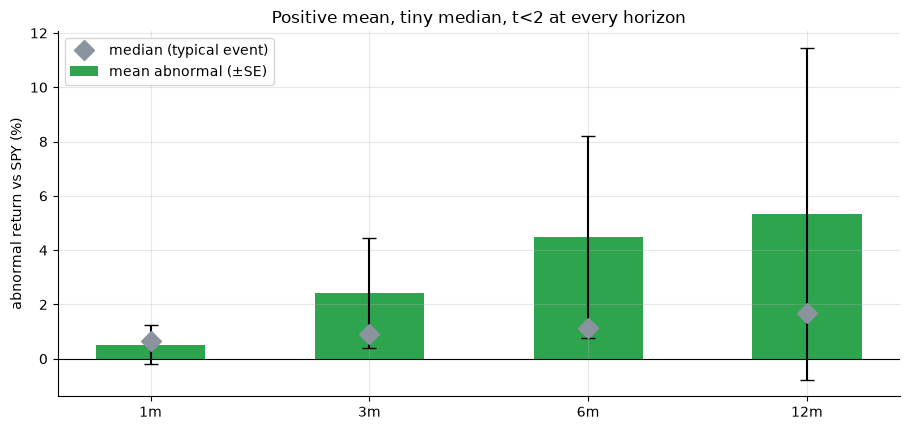

one-sample t by horizon: {'1m': 0.72, '3m': 1.19, '6m': 1.21, '12m': 0.87}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    am, md_, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(PRICES, EVENTS, m); am.append(s['ab_mean']); md_.append(s['ab_median']); ts.append(s['t'])
        ar = st.abnormal_returns(PRICES, EVENTS, m); ses.append(ar.std(ddof=1)/np.sqrt(len(ar)))
else:
    am = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    md_ = [R['h1'][3]/100, R['h3'][3]/100, R['h6'][3]/100, R['h12'][3]/100]
    ts = [R['h1'][5], R['h3'][5], R['h6'][5], R['h12'][5]]; ses = [0.007, 0.020, 0.037, 0.061]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [a*100 for a in am], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='mean abnormal (±SE)')
ax.plot(x, [m*100 for m in md_], 'D', ms=10, c=GREY, label='median (typical event)')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('abnormal return vs SPY (%)')
ax.set_title('Positive mean, tiny median, t<2 at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('one-sample t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 6 months the mean abnormal drift is **+4.5%** at **t = 1.21** — the *highest* t of any horizon and still nowhere near 2 — while the median is only **+1.1%**. H₁ is **not rejected, not supported**: a positive whisper, carried by a few outliers, inside its own error bar.

### 4b · The decisive test — a same-names placebo null

Re-enter each *same ticker* on 20,000 sets of random dates; the histogram is the null distribution of the 6-month mean abnormal return. The announcements are the green line; the *p*-value is the right-tail mass. This is stricter than a SPY-only baseline — it asks whether the **same stocks on random days** drift just as much.

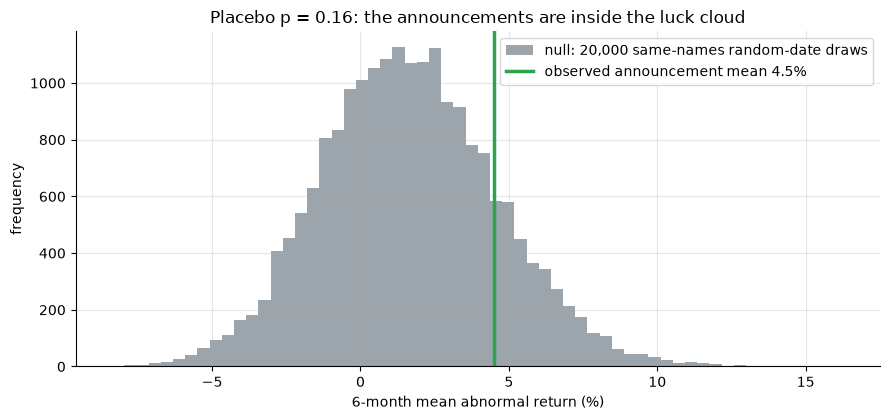

P[same-names random draw >= announcements] = 0.165  (need <0.05; here ~1 in 5-6)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PRICES, EVENTS, 6); obs = pl['ann_mean']; pval = pl['p_value']
    h = st.TRADING_DAYS[6]; spy = PRICES['SPY']; lag=1; pools=[]
    for _,row in EVENTS.iterrows():
        s = PRICES[row['ticker']].dropna(); idx=s.index; sp=spy.reindex(idx)
        sv,pv=s.values,sp.values; hi=len(idx)-h-lag-1
        if hi<=0: continue
        e=np.arange(lag,lag+hi); x=e+h
        ab=(sv[x]/sv[e]-1)-(pv[x]/pv[e]-1); ab=ab[np.isfinite(ab)]
        if len(ab): pools.append(ab)
    rng=np.random.default_rng(368)
    draws=np.array([np.mean([p[rng.integers(0,len(p))] for p in pools]) for _ in range(20000)])
else:
    obs = R['h6'][2]/100; pval = R['h6'][6]
    rng=np.random.default_rng(368); draws=rng.normal(0.016, 0.024, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} same-names random-date draws')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed announcement mean {obs*100:.1f}%')
ax.set_xlabel('6-month mean abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the announcements are inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[same-names random draw >= announcements] = {pval:.3f}  (need <0.05; here ~1 in 5-6)')

> 💡 In plain words: **16%** of same-names random-date draws match or beat the real announcements. A real edge would push the green line into the far right tail; instead it sits mid-cloud. This is the crux — not a weak point estimate alone, but one that **the same stocks on random days reproduce ~1 time in 5–6**. H₃ rejected: the drift is base-rate × a few lucky names, not the authorization.

### 4c · Robustness — the dose-response is inverted, and cost is irrelevant

If the authorization carries information, a *bigger* program should drift *more*. Split at the median program size (and apply a round-trip cost): the **bigger** programs drift **less**, and 10 bps barely dents a multi-month hold.

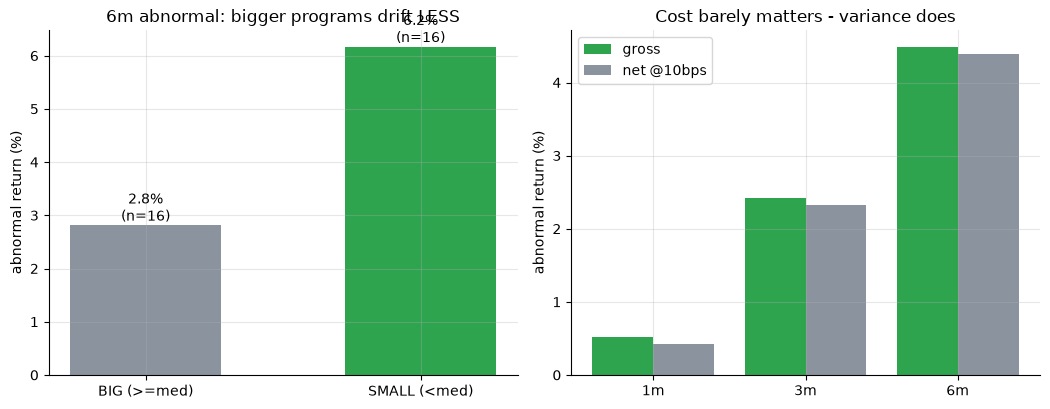

size split (label, n, ab6%, t, p): [('BIG (>=med)', 16, 2.8, 0.52, 0.612), ('SMALL (<med)', 16, 6.2, 1.19, 0.042)]


In [4]:
if HAVE_REAL:
    med = EVENTS['size_bn'].median()
    bigS = st.summarize(PRICES, EVENTS[EVENTS['size_bn']>=med], 6)
    smlS = st.summarize(PRICES, EVENTS[EVENTS['size_bn']<med], 6)
    size = [('BIG (>=med)', bigS['n'], bigS['ab_mean']*100, bigS['t'], bigS['p_placebo']),
            ('SMALL (<med)', smlS['n'], smlS['ab_mean']*100, smlS['t'], smlS['p_placebo'])]
    ms=[1,3,6]; g=[st.net_of_costs(PRICES,EVENTS,m,10.0)['gross_mean']*100 for m in ms]
    nv=[st.net_of_costs(PRICES,EVENTS,m,10.0)['net_mean']*100 for m in ms]
else:
    size = R['size']; ms=[1,3,6]; g=[r[1] for r in R['net']]; nv=[r[2] for r in R['net']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
lab=[s[0] for s in size]; mn=[s[2] for s in size]; nn=[s[1] for s in size]
a1.bar(lab, mn, color=[GREY, GREEN], width=.55)
for i,(v,k) in enumerate(zip(mn,nn)): a1.annotate(f'{v:.1f}%\n(n={k})',(i,v),ha='center',va='bottom')
a1.set_title('6m abnormal: bigger programs drift LESS'); a1.set_ylabel('abnormal return (%)')
x=np.arange(len(ms))
a2.bar(x-.2,g,.4,color=GREEN,label='gross'); a2.bar(x+.2,nv,.4,color=GREY,label='net @10bps')
a2.set_xticks(x); a2.set_xticklabels([f'{m}m' for m in ms]); a2.set_ylabel('abnormal return (%)')
a2.set_title('Cost barely matters - variance does'); a2.legend()
plt.tight_layout(); plt.show()
print('size split (label, n, ab6%, t, p):', [(s[0], s[1], round(s[2],1), round(s[3],2), round(s[4],3)) for s in size])

> 💡 In plain words: the **bigger** authorizations drift **+2.8%** (t = 0.52) vs **+6.2%** for the smaller — the dose-response is *backwards*. The SMALL bucket's placebo p looks low (**0.042**), but its t is only **1.19** and it doesn't hold at other horizons — a median-split multiple-testing fluke. Costs shave a handful of bps off a months-long hold. **The constraint is the event count and the variance, not cost.**

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic panel with **31 event windows** and a **known** planted abnormal drift: with **zero** planted drift the test must stay below t=2 (~30 noisy windows can't fake significance); with a **+15%/6m** planted drift it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large drifts.

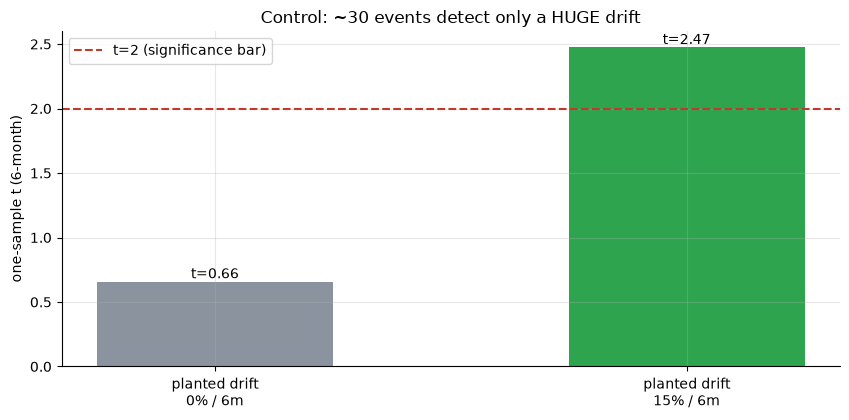

planted +0%/6m: detected=31 mean=2.6% t=0.66
planted +15%/6m: detected=31 mean=10.6% t=2.47


In [5]:
res = []
for edge in (0.0, 0.15):
    p2, e2 = data.synthetic_events(n_events=31, edge=edge, seed=368)
    s = st.summarize(p2, e2, 6)
    res.append((edge, s['n'], s['ab_mean']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f'planted drift\n{e*100:.0f}% / 6m' for e,_,_,_ in res]
tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t (6-month)'); ax.set_title('Control: ~30 events detect only a HUGE drift'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,t in res: print(f'planted {e*100:+.0f}%/6m: detected={k} mean={c:.1f}% t={t:.2f}')

> 💡 In plain words: with **no** real drift the control sits at **t = 0.66** (below 2 — no false positive); only a **+15%/6m** drift — enormous — reaches **t = 2.47**. So the machinery is honest, and the real-tape *t* of ~1.2 is exactly what an *absent or tiny* drift looks like through a 30-event keyhole. The sample size is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — abnormal drift positive at every horizon (peak **+4.5%** at 6m) but one-sample **t ≤ 1.21 < 2** throughout, median only **+1.1%**, win-rate ≈ coin-flip, placebo can't reject luck. Literature support + a positive-but-insignificant, outlier-driven estimate on a visibility/survivorship-selected sample ⇒ WEAK, not REAL.
- **Tradability `FRAGILE`** — **32 single-name events**; per-trade drift inside its SE; net of 10-bps costs intact; **inverted dose-response** (bigger programs drift less). Variance and event count, not cost, make it un-allocatable.
- **Free lunch? `BUSTED`** — a same-names placebo matches the record ~1 in 6; the documented move is the **day-0 jump** (~2–3%, excluded by the 1-day lag). The months-long drift is base rate × a few lucky names — the announcement *pop* is real, the tradable *drift* is not.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* 6-month abnormal drift have to be for a $k$-event study to detect it at t=2? At $k=32$ you'd need a drift several times the one observed; the real signal lives below the detection floor.

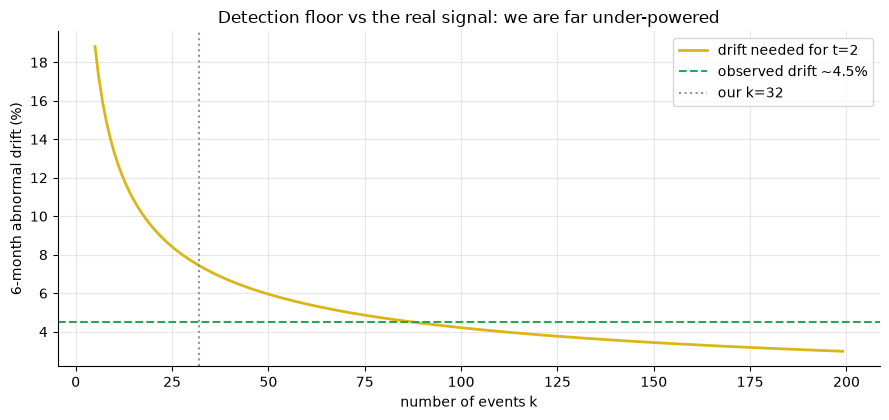

at k=32 you need ~7.4% drift for t=2; observed ~4.5% -> under-powered by ~1.7x


In [6]:
if HAVE_REAL:
    ar = st.abnormal_returns(PRICES, EVENTS, 6); sd = ar.std(ddof=1)
    obs_drift = R['h6'][2]/100
else:
    sd = 0.21; obs_drift = R['h6'][2]/100
ks = np.arange(5, 200)
min_detectable = 2.0 * sd / np.sqrt(ks)   # drift needed for t=2 (one-sample)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='drift needed for t=2')
ax.axhline(obs_drift*100, c=GREEN, ls='--', label=f'observed drift ~{obs_drift*100:.1f}%')
ax.axvline(R['n_events'], c=GREY, ls=':', label=f"our k={R['n_events']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('6-month abnormal drift (%)')
ax.set_title('Detection floor vs the real signal: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_events'])
print(f'at k={R["n_events"]} you need ~{need*100:.1f}% drift for t=2; observed ~{obs_drift*100:.1f}% -> under-powered by ~{need/obs_drift:.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable drift**; the green line is what we actually see. They don't meet until $k$ is many times larger than a hand-built headline set. Even granting the lore a *real* few-point drift, you'd need hundreds of clean, point-in-time authorizations to prove it — and the *bigger*-program result tells you the headline-size dose-response runs the wrong way. There is no sizing, no threshold, no cost assumption that manufactures power from 30 single-name events — **the variance that makes single stocks single stocks is exactly what makes this untestable on a hand-picked headline sample.**

## 7 · Going further

- **The real, missed move.** Measure the **day-0** announcement return (not day +1): the documented ~2–3% pop is a *jump* you've already missed, not a drift. The cleanest demonstration that the legend mislocates the effect in *time*.
- **Execution ≠ authorization.** Authorized ≠ repurchased (completion rates are low and variable; Stephens & Weisbach 1998). A drift study on *actual* share-count reduction is a different, slower, and arguably cleaner test.
- **A real panel.** Replace the 32-name headline sample with a point-in-time universe of *all* authorizations (incl. the small, unglamorous ones) and a proper factor model (FF/Carhart abnormal returns); the event count rises but the ILV-style drift is known to decay post-publication (McLean & Pontiff 2016).

*The reproducible core is offline and deterministic; the event set is an explicit hand-curated sample. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*